In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-132.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-308.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-292.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-325.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-373.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-148.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-251.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-438.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-390.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-38.jpg
/kaggle/input/dataset

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [56]:
import os

dataset_path = "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data"

total_images = 0
class_counts = {}

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images
        total_images += num_images

print("Total Images:", total_images)
print("\nImages per class:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Total Images: 2631

Images per class:
brown spots: 470
healthy: 1203
white scale: 958


In [85]:
import os

print(os.listdir(dataset_path))

['brown spots', 'healthy', 'white scale']


In [86]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "/kaggle/input/date-palm-data/train"


In [88]:
IMG_SIZE = 256
BATCH_SIZE = 32

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest',
    validation_split=0.2
)

# Training data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Validation data (NO augmentation ideally)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🔥 MUST ADD THIS
)

Found 2106 images belonging to 3 classes.
Found 525 images belonging to 3 classes.


In [89]:
print(train_generator.class_indices)

{'brown spots': 0, 'healthy': 1, 'white scale': 2}


In [90]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.)(x)

output = Dense(3, activation='softmax')(x)  # 3 classes

model = Model(inputs=base_model.input, outputs=output)

In [91]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [109]:
class_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights_dict = dict(enumerate(class_weights))

In [110]:
# Increase importance of brown spots (class 0)
class_weights_dict[0] *= 1.3  

# Keep others same
class_weights_dict[1] *= 1.0  
class_weights_dict[2] *= 1.0  

print(class_weights_dict)

{0: np.float64(2.427127659574468), 1: np.float64(0.7289719626168224), 2: np.float64(0.9152542372881356)}


In [111]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_resnet50.h5", save_best_only=True)
]

In [112]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.8870 - loss: 0.4470

66/66 ━━━━━━━━━━━━━━━━━━━━ 41s 625ms/step - accuracy: 0.8872 - loss: 0.4468 - val_accuracy: 0.7105 - val_loss: 1.0609 - learning_rate: 1.0000e-06
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.8881 - loss: 0.4390

66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 576ms/step - accuracy: 0.8883 - loss: 0.4386 - val_accuracy: 0.7638 - val_loss: 1.0480 - learning_rate: 1.0000e-06
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 560ms/step - accuracy: 0.8897 - loss: 0.4173 - val_accuracy: 0.7219 - val_loss: 1.0731 - learning_rate: 1.0000e-06
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 566ms/step - accuracy: 0.9075 - loss: 0.4231 - val_accuracy: 0.7276 - val_loss: 1.0760 - learning_rate: 1.0000e-06
Epoch 5/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 555ms/step - accuracy: 0.9098 - loss: 0.4228 - val_accuracy: 0.7619 - val_loss: 1.0743 - learning_rate: 1.0000e-06
Epoch 6/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 555ms/step - accuracy: 0.9078 - loss: 0.3971 - val_accuracy: 0.6781 - val_loss: 1.2139 - learning_rate: 1.0000e-06
Epoch 7/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 557ms/step - accuracy: 0.9039 - loss: 0.3775 - val_accuracy: 0.6648 - val_loss: 1.2872 - learning_rate: 1.0000e-06
Epoch 8/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 557ms/step - accuracy: 0.91

In [113]:
# Unfreeze top layers
from tensorflow.keras.losses import CategoricalCrossentropy
for layer in base_model.layers[-60:]:
    layer.trainable = True

loss = CategoricalCrossentropy(label_smoothing=0.05)


model.compile(
    optimizer = Adam(learning_rate=1e-5, clipnorm=1.0),
    loss=loss,
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 97s 906ms/step - accuracy: 0.8857 - loss: 0.4498 - val_accuracy: 0.7162 - val_loss: 1.2529 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 566ms/step - accuracy: 0.8684 - loss: 0.4555 - val_accuracy: 0.7638 - val_loss: 1.1783 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.8714 - loss: 0.4613

66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 582ms/step - accuracy: 0.8713 - loss: 0.4614 - val_accuracy: 0.8057 - val_loss: 0.8405 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.8837 - loss: 0.4282

66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 570ms/step - accuracy: 0.8837 - loss: 0.4282 - val_accuracy: 0.8590 - val_loss: 0.7292 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 557ms/step - accuracy: 0.8790 - loss: 0.4282 - val_accuracy: 0.6038 - val_loss: 1.2774 - learning_rate: 1.0000e-05
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 553ms/step - accuracy: 0.9006 - loss: 0.4108 - val_accuracy: 0.5924 - val_loss: 1.2424 - learning_rate: 1.0000e-05
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.9055 - loss: 0.4080

66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 583ms/step - accuracy: 0.9055 - loss: 0.4081 - val_accuracy: 0.8571 - val_loss: 0.6297 - learning_rate: 1.0000e-05
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 553ms/step - accuracy: 0.9069 - loss: 0.4016 - val_accuracy: 0.8057 - val_loss: 0.9330 - learning_rate: 1.0000e-05
Epoch 9/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 559ms/step - accuracy: 0.9008 - loss: 0.4376 - val_accuracy: 0.5905 - val_loss: 1.3227 - learning_rate: 1.0000e-05
Epoch 10/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 562ms/step - accuracy: 0.9095 - loss: 0.4095 - val_accuracy: 0.6971 - val_loss: 0.8822 - learning_rate: 1.0000e-05
Epoch 11/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 544ms/step - accuracy: 0.9260 - loss: 0.3728 - val_accuracy: 0.7714 - val_loss: 0.8420 - learning_rate: 3.0000e-06
Epoch 12/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 549ms/step - accuracy: 0.9208 - loss: 0.3649 - val_accuracy: 0.7429 - val_loss: 0.9173 - learning_rate: 3.0000e-06
Epoch 13/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 

17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 328ms/step


<Figure size 600x600 with 0 Axes>

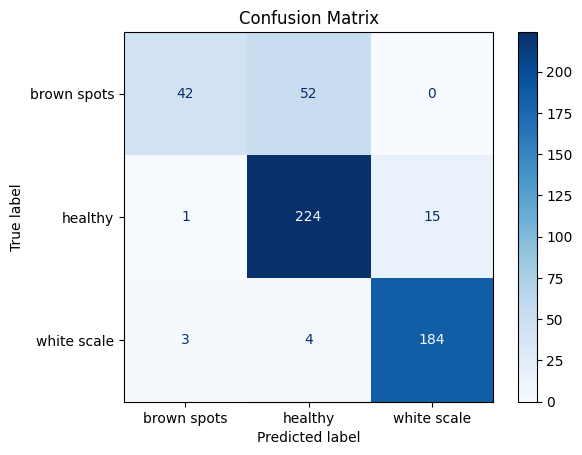

In [114]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels
y_true = val_generator.classes

val_generator.reset()
# Get predictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(val_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

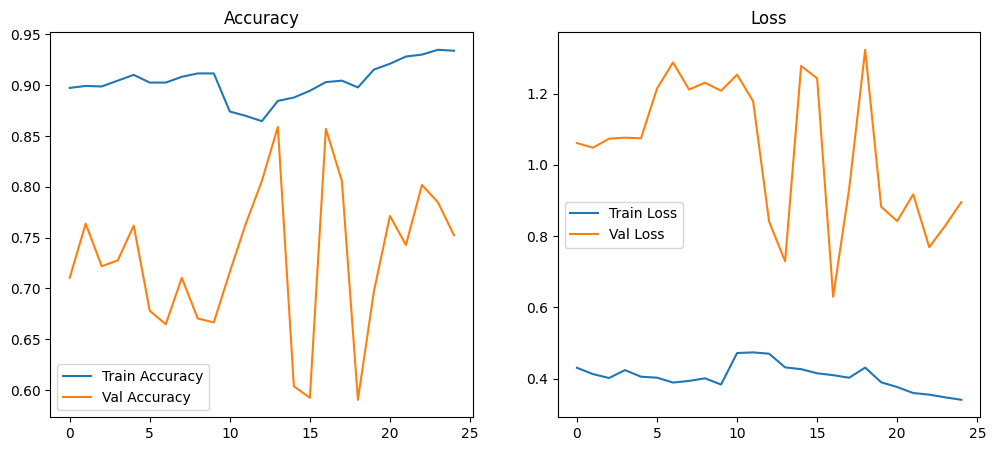

In [115]:
import matplotlib.pyplot as plt

acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [117]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Reset generator
val_generator.reset()

# Predictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_generator.classes

# Class names
class_names = list(val_generator.class_indices.keys())

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1 (macro = balanced for all classes)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

# Full detailed report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step
Accuracy : 0.8571428571428571
Precision: 0.879222197946253
Recall   : 0.7811642097706485
F1 Score : 0.8017094017094019

Classification Report:

              precision    recall  f1-score   support

 brown spots       0.91      0.45      0.60        94
     healthy       0.80      0.93      0.86       240
 white scale       0.92      0.96      0.94       191

    accuracy                           0.86       525
   macro avg       0.88      0.78      0.80       525
weighted avg       0.87      0.86      0.84       525

